In [3]:
# Instalar dependencias
!pip install git+https://github.com/huggingface/transformers.git
!pip install accelerate timm

from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch
import json
import matplotlib.pyplot as plt




  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-18la1s9l
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-18la1s9l
  Resolved https://github.com/huggingface/transformers.git to commit c587bc884db2c2e31fc2b8102314656b17aa07b1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
# Cargar modelo y procesador
model_name = "naver-clova-ix/donut-base-finetuned-cord-v2"
processor = DonutProcessor.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name)



Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

In [ ]:
# Cargar imagen
import os
from PIL import Image, ImageDraw, ImageFont

# Ruta de la imagen a analizar.
# - En local: 'image.png' (la factura del workspace) o ruta completa.
# - En Colab: sube la foto y usa p.ej. '/content/image.png'.
image_path = "image.png"

if os.path.exists(image_path):
    image = Image.open(image_path).convert("RGB")
    print("Usando imagen:", image_path)
else:
    print(f"No se encontro '{image_path}'. Genero un recibo sintetico.")
    image = Image.new("RGB", (480, 560), color="white")
    _d = ImageDraw.Draw(image)
    def _f(s):
        try:
            return ImageFont.truetype("DejaVuSans.ttf", s)
        except OSError:
            return ImageFont.load_default()
    _d.text((20, 20), "CAFE CENTRAL", fill="black", font=_f(26))
    _d.text((20, 60), "Fecha: 2024-05-14", fill="black", font=_f(16))
    _y = 110
    for _n, _p in [("Cafe Americano", "3.50"), ("Croissant", "2.75"), ("Jugo Naranja", "4.20")]:
        _d.text((20, _y), _n, fill="black", font=_f(18))
        _d.text((360, _y), _p, fill="black", font=_f(18))
        _y += 34
    _d.text((20, _y + 24), "TOTAL", fill="black", font=_f(20))
    _d.text((360, _y + 24), "10.45", fill="black", font=_f(20))

# Preprocesar imagen
pixel_values = processor(image, return_tensors="pt").pixel_values



In [6]:
# Definir prompt
task_prompt = "<s_cord-v2>"
decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids

# Generar salida
outputs = model.generate(pixel_values,
                         decoder_input_ids=decoder_input_ids,
                         max_length=512)

# Decodificar resultado
result = processor.tokenizer.decode(outputs[0], skip_special_tokens=True)



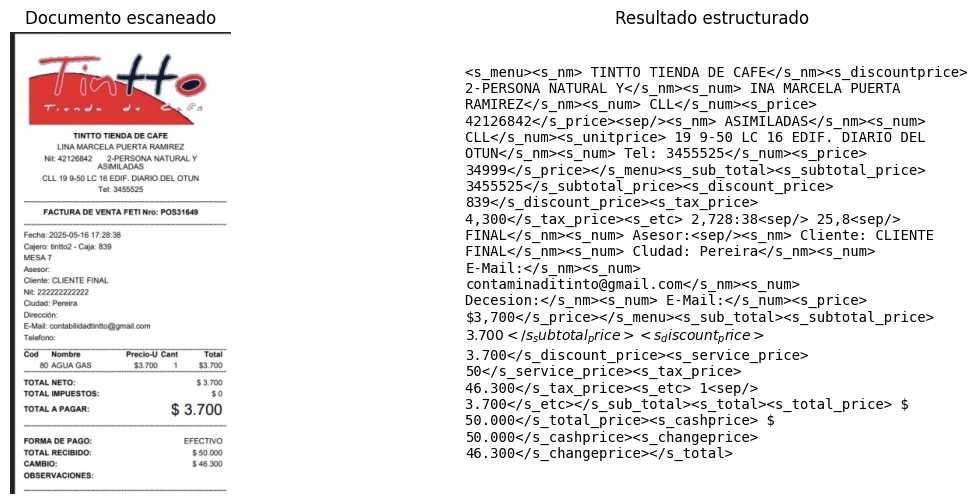

In [8]:
import matplotlib.pyplot as plt
import textwrap
import json

# Mostrar imagen y resultado
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Imagen original
ax[0].imshow(image)
ax[0].axis("off")
ax[0].set_title("Documento escaneado")

# Intentar parsear como JSON
try:
    formatted_json = json.dumps(json.loads(result), indent=4, ensure_ascii=False)
except:
    # Si no es JSON válido, mostrar como texto plano
    formatted_json = result

# Ajustar texto para que se vea bien
wrapped_text = "\n".join(textwrap.wrap(formatted_json, width=60))
ax[1].text(0, 0.5, wrapped_text, fontsize=10, va="center", ha="left", family="monospace")
ax[1].axis("off")
ax[1].set_title("Resultado estructurado")

plt.show()